#### Requirements

In [4]:
!pip install prettytable
!pip install -q -U keras-tuner

#### Imports

In [5]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import re
from collections import Counter
import prettytable
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib import request

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import TweetTokenizer
from nltk.stem.snowball import SnowballStemmer

nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')
nltk.download('wordnet')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import confusion_matrix

import tensorflow as tf
import keras_tuner as kt
from keras import backend as K
from keras.utils import plot_model

module_url = [f'https://drive.usercontent.google.com/u/0/uc?id=1zrnbbbn_SDYYJfpco_1T1Xz7x8QPdiek&export=download',
              f'https://drive.usercontent.google.com/u/0/uc?id=1i4bmjIbOVdA-c91Vejua1Owie9Pjfd4S&export=download',
              f'https://drive.usercontent.google.com/u/0/uc?id=1bmMYGszVDew2MdSFy3qz417j3cDWcqot&export=download']

name = ['dev_en.tsv', 'test_en.tsv', 'train_en.tsv']
for i in range(len(name)):
    with request.urlopen(module_url[i]) as f, open(name[i],'w') as outf:
        a = f.read()
        outf.write(a.decode('UTF-8'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [6]:
module_url = [f'https://drive.usercontent.google.com/u/0/uc?id=1zrnbbbn_SDYYJfpco_1T1Xz7x8QPdiek&export=download',
              f'https://drive.usercontent.google.com/u/0/uc?id=1i4bmjIbOVdA-c91Vejua1Owie9Pjfd4S&export=download',
              f'https://drive.usercontent.google.com/u/0/uc?id=1bmMYGszVDew2MdSFy3qz417j3cDWcqot&export=download']

name = ['dev_en.tsv', 'test_en.tsv', 'train_en.tsv']
for i in range(len(name)):
    with request.urlopen(module_url[i]) as f, open(name[i],'w') as outf:
        a = f.read()
        outf.write(a.decode('UTF-8'))

#### Read files into dataframes

In [7]:
dev_df = pd.read_csv('dev_en.tsv', sep='\t')
test_df = pd.read_csv('test_en.tsv', sep='\t', header=None)
train_df = pd.read_csv('train_en.tsv', sep='\t')

#### Dev dataset shape

In [8]:
print(dev_df.columns)
print(len(dev_df))

Index(['id', 'text', 'HS', 'TR', 'AG'], dtype='object')
1000


### Test dataset shape

In [9]:
print(test_df.columns)
print(len(test_df))
test_df.columns = ['id', 'text', 'HS', 'TR', 'AG']

Index([0, 1, 2, 3, 4], dtype='int64')
2971


### Train dataset shape

In [10]:
print(train_df.columns)
print(len(train_df))

Index(['id', 'text', 'HS', 'TR', 'AG'], dtype='object')
9000


### Getting into training dataset

In [11]:
train_df.head()

,id,text,HS,TR,AG
0,201,"Hurray, saving us $$$ in so many ways @potus @...",1,0,0
1,202,Why would young fighting age men be the vast m...,1,0,0
2,203,@KamalaHarris Illegals Dump their Kids at the ...,1,0,0
3,204,NY Times: 'Nearly All White' States Pose 'an A...,0,0,0
4,205,Orban in Brussels: European leaders are ignori...,0,0,0


### Label Stats

In [12]:
for label in ['HS', 'TR', 'AG']:
  print(label)
  label_stats = prettytable.PrettyTable(['Dataset', 0, 1])
  label_stats.add_row(['train', len(train_df[train_df[label] == 0]), len(train_df[train_df[label] == 1])])
  label_stats.add_row(['dev', len(dev_df[dev_df[label] == 0]), len(dev_df[dev_df[label] == 1])])
  label_stats.add_row(['test', len(test_df[test_df[label] == 0]), len(test_df[test_df[label] == 1])])
  print(label_stats)

HS
+---------+------+------+
| Dataset |  0   |  1   |
+---------+------+------+
|  train  | 5217 | 3783 |
|   dev   | 573  | 427  |
|   test  | 1719 | 1252 |
+---------+------+------+
TR
+---------+------+------+
| Dataset |  0   |  1   |
+---------+------+------+
|  train  | 7659 | 1341 |
|   dev   | 781  | 219  |
|   test  | 2449 | 522  |
+---------+------+------+
AG
+---------+------+------+
| Dataset |  0   |  1   |
+---------+------+------+
|  train  | 7441 | 1559 |
|   dev   | 796  | 204  |
|   test  | 2381 | 590  |
+---------+------+------+


### Histogram for Tweet Length (Word count)

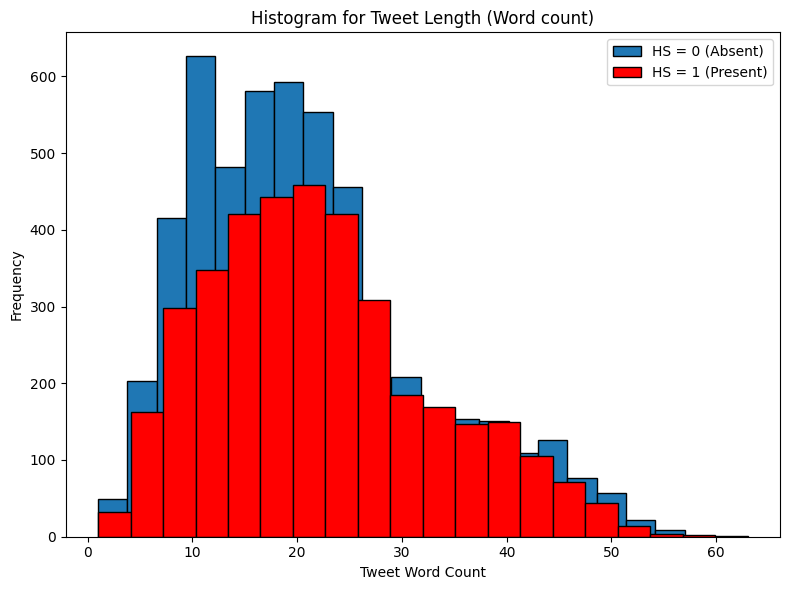

+-------+--------------------+--------------------+
|  Stat |    Val (No HS)     |      Val (HS)      |
+-------+--------------------+--------------------+
| count |       5217.0       |       3783.0       |
|  mean | 20.729538048686983 | 22.187681734073486 |
|  std  | 10.96305300060505  | 10.643454154188527 |
|  min  |        1.0         |        1.0         |
|  25%  |        13.0        |        14.0        |
|  50%  |        19.0        |        21.0        |
|  75%  |        26.0        |        28.0        |
|  max  |        57.0        |        63.0        |
+-------+--------------------+--------------------+


In [13]:
word_counts_0 = [len(tweet.split()) for tweet in train_df[train_df['HS'] == 0]['text']]
word_counts_1 = [len(tweet.split()) for tweet in train_df[train_df['HS'] == 1]['text']]

# Create a figure and a set of subplots
fig, axs = plt.subplots(figsize=(8, 6))

# Plot histogram on the first subplot
axs.hist(word_counts_0, bins=20, edgecolor='black', label='HS = 0 (Absent)')
axs.set_title('Histogram for Tweet Length (Word count)')
axs.set_xlabel('Word Count: HS')
axs.set_ylabel('Frequency')

# Plot histogram on the first subplot
axs.hist(word_counts_1, bins=20, edgecolor='black', color = 'red', label='HS = 1 (Present)')
#axs[0].set_title('Histogram for Tweet Length (Word count): No Hate Speech')
axs.set_xlabel('Tweet Word Count')
axs.set_ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()

plt.legend()

# Show the plots
plt.show()

# stats summary
describe_0 = pd.Series(word_counts_0).describe()
describe_1 = pd.Series(word_counts_1).describe()
dict_list = []
table = prettytable.PrettyTable(['Stat', 'Val (No HS)', 'Val (HS)'])
for col in describe_0.index:
  table.add_row([col, describe_0[col], describe_1[col]])
  dict_list.append({'Stat': col, 'Val (No HS)': describe_0[col], 'Val (HS)': describe_1[col]})
print(table)
pd.DataFrame(dict_list).to_csv('word_count.csv')

### Boxplot for Tweet Length (Word Count)

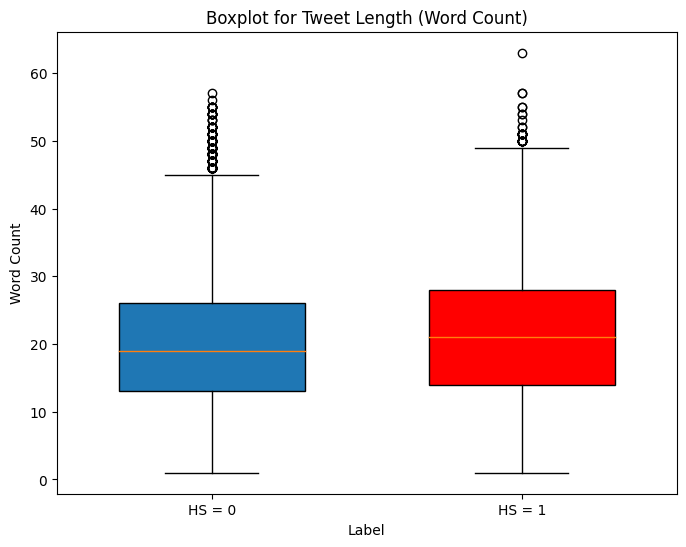

In [14]:
# Assuming word_counts_0 and word_counts_1 are already defined from your previous code

# Data preparation for the boxplot
data = [word_counts_0, word_counts_1]  # Combine the two lists into a list of lists

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Create the boxplot
# The 'positions' argument determines the positions of the box plots. You can adjust these values if needed.
# The 'labels' argument specifies the labels for each boxplot.
bp = ax.boxplot(data, positions=[1, 2], widths=0.6, patch_artist=True, labels=['HS = 0', 'HS = 1'])

bp['boxes'][1].set_facecolor('red')

# Adding titles and labels
ax.set_title('Boxplot for Tweet Length (Word Count)')
ax.set_xlabel('Label')
ax.set_ylabel('Word Count')
ax.set_xticks([1, 2])  # This ensures that the x-axis only has ticks for our two categories

# Show the plot
plt.show()

### Histogram for Tweet Length (Character count)

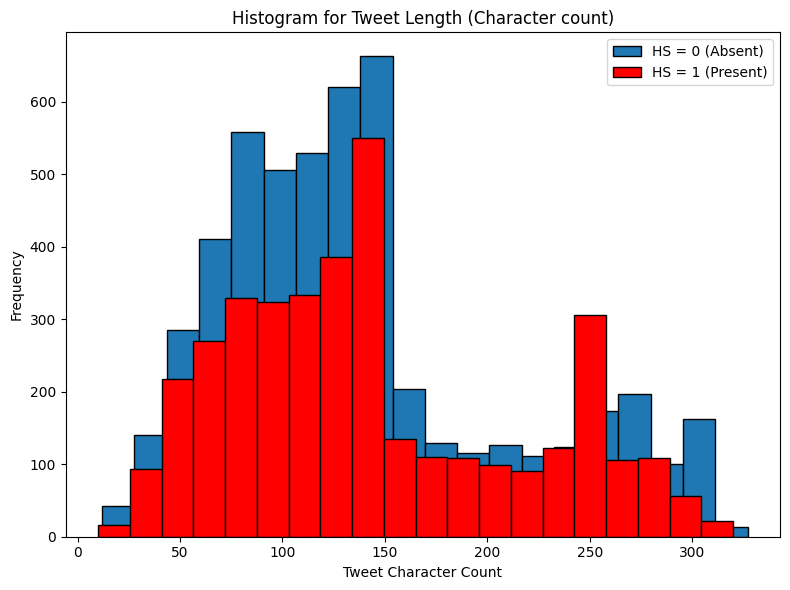

+-------+--------------------+--------------------+
|  Stat |      Val (HS)      |    Val (No HS)     |
+-------+--------------------+--------------------+
| count |       5217.0       |       3783.0       |
|  mean | 138.12210082422848 | 142.58604282315622 |
|  std  | 69.92238688877639  |  70.8972855892905  |
|  min  |        12.0        |        10.0        |
|  25%  |        87.0        |        88.0        |
|  50%  |       127.0        |       131.0        |
|  75%  |       164.0        |       190.0        |
|  max  |       327.0        |       320.0        |
+-------+--------------------+--------------------+


In [15]:
word_counts_0 = [len(tweet) for tweet in train_df[train_df['HS'] == 0]['text']]
word_counts_1 = [len(tweet) for tweet in train_df[train_df['HS'] == 1]['text']]

# Create a figure and a set of subplots
fig, axs = plt.subplots(figsize=(8, 6))

# Plot histogram on the first subplot
axs.hist(word_counts_0, bins=20, edgecolor='black', label='HS = 0 (Absent)')
axs.set_title('Histogram for Tweet Length (Character count)')
axs.set_xlabel('Word Count: HS')
axs.set_ylabel('Frequency')

# Plot histogram on the first subplot
axs.hist(word_counts_1, bins=20, edgecolor='black', color='red', label='HS = 1 (Present)')
#axs[0].set_title('Histogram for Tweet Length (Word count): No Hate Speech')
axs.set_xlabel('Tweet Character Count')
axs.set_ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()

plt.legend()

# Show the plots
plt.show()

# stats summary
describe_0 = pd.Series(word_counts_0).describe()
describe_1 = pd.Series(word_counts_1).describe()
dict_list = []
table = prettytable.PrettyTable(['Stat', 'Val (HS)', 'Val (No HS)'])
for col in describe_0.index:
  table.add_row([col, describe_0[col], describe_1[col]])
  dict_list.append({'Stat': col, 'Val (HS)': describe_0[col], 'Val (No HS)': describe_1[col]})
print(table)
pd.DataFrame(dict_list).to_csv('character_count.csv')

### Boxplot for Tweet Length (Character Count)

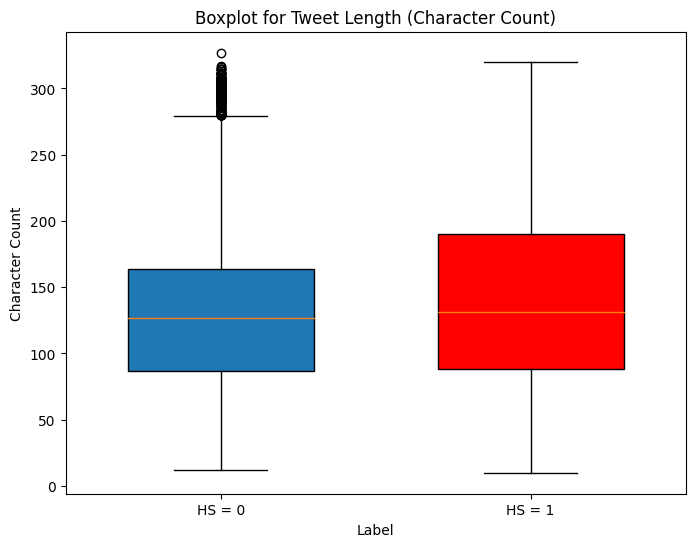

In [16]:
# Assuming word_counts_0 and word_counts_1 are already defined from your previous code

# Data preparation for the boxplot
data = [word_counts_0, word_counts_1]  # Combine the two lists into a list of lists

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Create the boxplot
# The 'positions' argument determines the positions of the box plots. You can adjust these values if needed.
# The 'labels' argument specifies the labels for each boxplot.
bp = ax.boxplot(data, positions=[1, 2], widths=0.6, patch_artist=True, labels=['HS = 0', 'HS = 1'])

bp['boxes'][1].set_facecolor('red')

# Adding titles and labels
ax.set_title('Boxplot for Tweet Length (Character Count)')
ax.set_xlabel('Label')
ax.set_ylabel('Character Count')
ax.set_xticks([1, 2])  # This ensures that the x-axis only has ticks for our two categories

# Show the plot
plt.show()

### Non-hateful Wordcloud

(-0.5, 399.5, 199.5, -0.5)

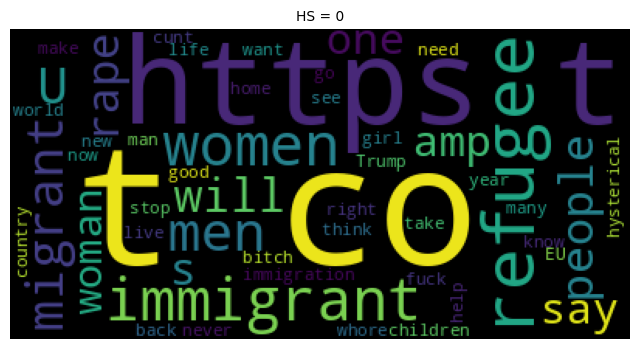

In [17]:
combined_tweets = " ".join([tweet for tweet in train_df[train_df['HS']==0]['text']])

# Initialize wordcloud object
wc = WordCloud(background_color='black',
                   max_words=50,
                   stopwords = STOPWORDS)

# Generate and plot wordcloud
plt.figure(figsize=((8,8)))
plt.imshow(wc.generate(combined_tweets))
plt.title('HS = 0', fontsize=10)
plt.axis('off')

### Hateful Wordcloud

(-0.5, 399.5, 199.5, -0.5)

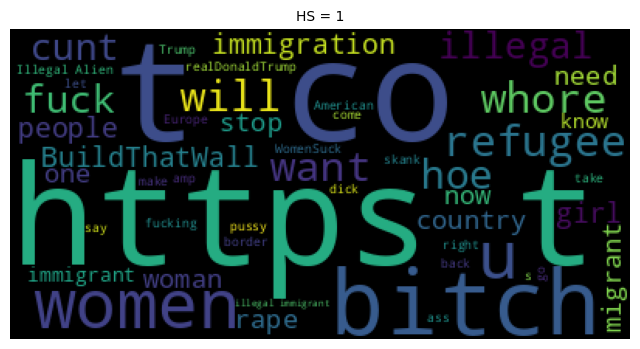

In [18]:
combined_tweets = " ".join([tweet for tweet in train_df[train_df['HS']==1]['text']])

# Initialize wordcloud object
wc = WordCloud(background_color='black',
                   max_words=50,
                   stopwords = STOPWORDS)

# Generate and plot wordcloud
plt.figure(figsize=((8,8)))
plt.imshow(wc.generate(combined_tweets))
plt.title('HS = 1', fontsize=10)
plt.axis('off')

### Hashtag Analysis

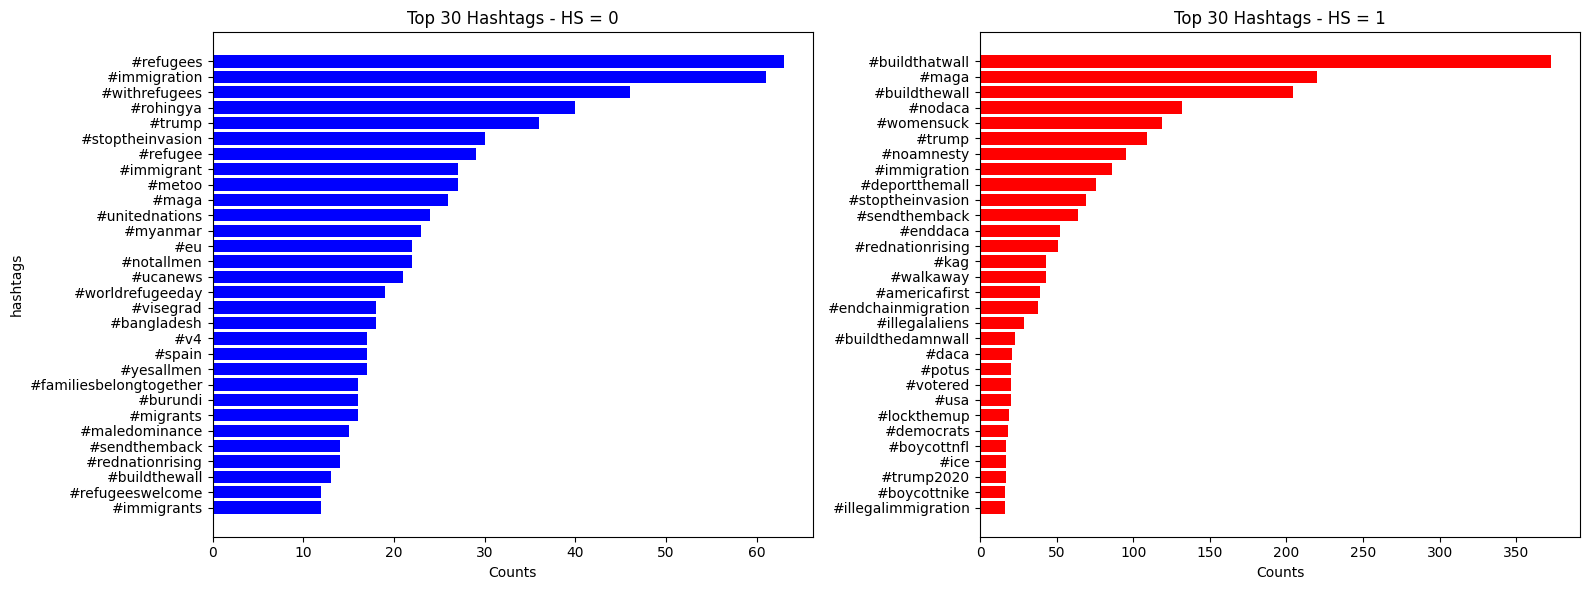

In [19]:
def extract_hashtags(text):
    # Use a regular expression to find all words starting with '#'
    hashtags = re.findall(r'#\w+', text)
    return hashtags

def top_hashtag_analysis(train_df):
    # Create a figure with two subplots side-by-side
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

    # Iterate over hs_value to create separate bar charts for each
    for index, hs_value in enumerate([0, 1]):
        specific_df = train_df[train_df['HS'] == hs_value]['text'].dropna().apply(extract_hashtags) if hs_value is not None else train_df['text'].apply(extract_hashtags)
        all_words = [word.lower() for sublist in specific_df for word in sublist if word.lower() not in STOPWORDS]
        word_count = Counter(all_words)

        words, counts = zip(*word_count.most_common(30))
        color = 'blue' if hs_value == 0 else 'red'

        # Plotting on the specific subplot
        axs[index].barh(words[::-1], counts[::-1], color=color)
        axs[index].set_xlabel('Counts')
        axs[index].set_title(f'Top 30 Hashtags - HS = {hs_value}')

        # Only set ylabel for the first subplot
        if index == 0:
            axs[index].set_ylabel('hashtags')

    # Adjust the layout
    plt.tight_layout()
    plt.show()

top_hashtag_analysis(train_df)

### Bigram Analysis

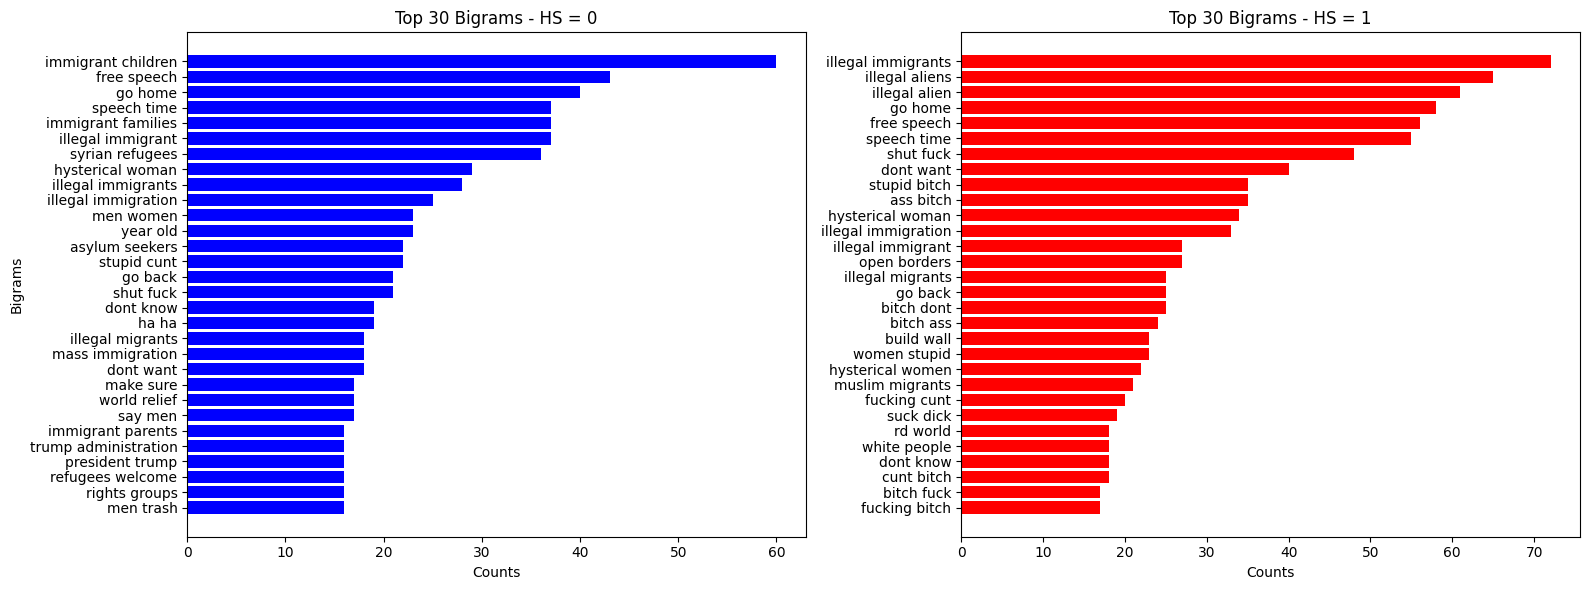

In [20]:
def extract_bigrams(text):
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    # Remove Twitter handles
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)
    # Remove all non-words and digits
    text = re.sub(r'[^A-Za-z\s]', '', text)
    # Tokenize by words
    words = re.findall(r'\w+', text)
    # Filter out single character words and stopwords
    words = [word.lower() for word in words if len(word) > 1 and word.lower() not in STOPWORDS]
    # Generate bigrams
    bigram_pairs = nltk.bigrams(words)
    # Return a list of bigram tuples
    return list(bigram_pairs)

def top_bigrams_analysis(train_df):
    # Create a figure with two subplots side-by-side
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

    for index, hs_value in enumerate([0, 1]):
        specific_df = train_df[train_df['HS'] == hs_value]['text'].dropna()
        all_bigrams = [bigram for tweet in specific_df for bigram in extract_bigrams(tweet)]
        bigram_count = Counter(all_bigrams)

        bigrams, counts = zip(*bigram_count.most_common(30))
        bigrams = [' '.join(bigram) for bigram in bigrams]  # Convert tuple to string
        color = 'blue' if hs_value == 0 else 'red'

        axs[index].barh(bigrams[::-1], counts[::-1], color=color)
        axs[index].set_xlabel('Counts')
        axs[index].set_title(f'Top 30 Bigrams - HS = {hs_value}')

        if index == 0:
            axs[index].set_ylabel('Bigrams')

    plt.tight_layout()
    plt.show()

# Example usage:
# top_bigrams_analysis(train_df)  # Replace 'train_df' with your actual DataFrame variable
top_bigrams_analysis(train_df)

### Trigram Analysis

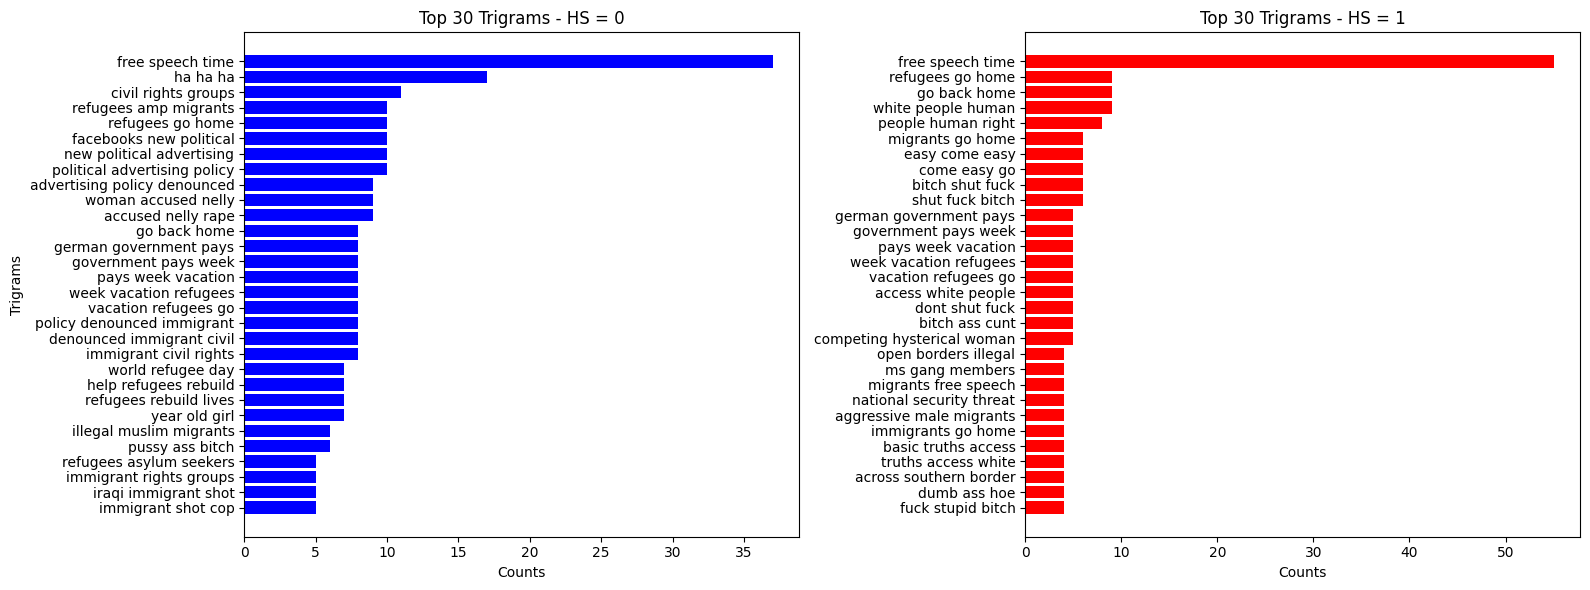

In [21]:
def extract_trigrams(text):
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    # Remove Twitter handles
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)
    # Remove all non-words and digits
    text = re.sub(r'[^A-Za-z\s]', '', text)
    # Tokenize by words
    words = re.findall(r'\w+', text)
    # Filter out single character words and stopwords
    words = [word.lower() for word in words if len(word) > 1 and word.lower() not in STOPWORDS]
    # Generate trigrams
    trigram_pairs = nltk.trigrams(words)
    # Return a list of trigram tuples
    return list(trigram_pairs)

def top_trigrams_analysis(train_df):
    # Create a figure with two subplots side-by-side
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

    for index, hs_value in enumerate([0, 1]):
        specific_df = train_df[train_df['HS'] == hs_value]['text'].dropna()
        all_trigrams = [trigram for tweet in specific_df for trigram in extract_trigrams(tweet)]
        trigram_count = Counter(all_trigrams)

        trigrams, counts = zip(*trigram_count.most_common(30))
        trigrams = [' '.join(trigram) for trigram in trigrams]  # Convert tuple to string
        color = 'blue' if hs_value == 0 else 'red'

        axs[index].barh(trigrams[::-1], counts[::-1], color=color)
        axs[index].set_xlabel('Counts')
        axs[index].set_title(f'Top 30 Trigrams - HS = {hs_value}')

        if index == 0:
            axs[index].set_ylabel('Trigrams')

    plt.tight_layout()
    plt.show()

# Example usage:
# top_trigrams_analysis(train_df)  # Replace 'train_df' with your actual DataFrame variable
top_trigrams_analysis(train_df)